## IMPORTS & CONFIGURATION

## 🧠 JUSTIFICATION DES CHOIX TECHNIQUES

### 1. Cross-Validation (Validation Croisée)
Plutôt que de se fier à un seul découpage Train/Test, nous utilisons la **Cross-Validation (K-Fold)**. 
- **Pourquoi ?** Cela permet de s'assurer que la performance du modèle est stable et ne dépend pas d'un "coup de chance" lors du split initial. C'est crucial pour valider la robustesse de nos modèles.

### 2. Hyperparameter Tuning (Optimisation des Hyperparamètres)
Chaque algorithme (Logistic Regression, SVM) possède des réglages internes (ex: `C`, `kernel`).
- **Pourquoi ?** Les valeurs par défaut ne sont pas toujours optimales. En utilisant `GridSearchCV`, nous testons systématiquement plusieurs combinaisons pour trouver celle qui maximise le **F1-Score**.

### 3. Analyse d'Erreurs
Au-delà de l'accuracy, nous analysons les **matrices de confusion** et les **exemples mal classés**.
- **Pourquoi ?** Comprendre si le modèle confond le "Négatif" avec le "Neutre" nous permet d'affiner le prétraitement ou de collecter plus de données spécifiques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer
)
import joblib
import pickle

### 1. CHARGER LES VECTEURS & LABELS

Chargement des données vectorisées et labels...
 TF-IDF shape : (500, 75)
 SBERT shape  : (500, 384)
 Classes détectées : ['negative', 'neutral', 'positive']
 Distribution : {'negative': 175, 'neutral': 171, 'positive': 154}
 Distribution : {'negative': 175, 'neutral': 171, 'positive': 154}


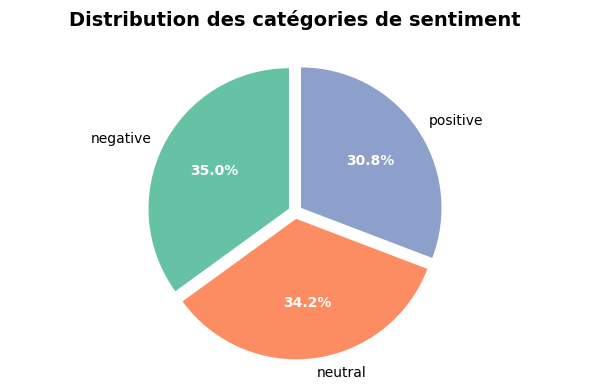

In [2]:
import matplotlib.pyplot as plt
print("Chargement des données vectorisées et labels...")

PATH_FEATURES = "../../outputs/results/"
PATH_RAW = "../../data/processed/mono-langue_clean.csv"

# 1. Charger les vecteurs
X_tfidf = load_npz(f"{PATH_FEATURES}mono_tfidf.npz")
X_sbert = np.load(f"{PATH_FEATURES}mono_sbert.npy")

# 2. Charger les métadonnées
with open(f"{PATH_FEATURES}sbert_metadata.pkl", 'rb') as f:
    metadata = pickle.load(f)

# 3. Charger le dataset original
df_full = pd.read_csv(PATH_RAW)

# Charger les deux colonnes de texte séparément
texts_classique = df_full['text_clean_classique'].fillna('').values
texts_light = df_full['text_clean_light'].fillna('').values

# Alias pour l'analyse d'erreurs
texts = texts_classique

# Labels
y_labels = df_full['sentiment'].fillna('neutral').values

# Encodage des labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
class_names = le.classes_

print(f" TF-IDF shape : {X_tfidf.shape}")
print(f" SBERT shape  : {X_sbert.shape}")
print(f" Classes détectées : {list(class_names)}")
print(f" Distribution : {pd.Series(y_labels).value_counts().to_dict()}")
import matplotlib.pyplot as plt



print(f" Distribution : {pd.Series(y_labels).value_counts().to_dict()}")

# === GRAPHE CIRCULAIRE : Distribution des sentiments ===
plt.figure(figsize=(6 ,4))

# Comptage des valeurs
counts = pd.Series(y_labels).value_counts()

# Création du pie chart
wedges, texts, autotexts = plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set2.colors[:len(counts)],  # Palette de couleurs
    textprops={'fontsize': 10},
    explode=[0.05] * len(counts)  # Légère séparation des sections
)

# Style des pourcentages
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Distribution des catégories de sentiment', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')  # Assure un cercle parfait
plt.tight_layout()
plt.show()

### 🔹 CROSS-VALIDATION

In [3]:
# === 🔹 CROSS-VALIDATION (Validation de la robustesse) ===
print("Calcul de la performance moyenne par Cross-Validation (5-folds)...")

# On définit un scorer (F1-weighted est robuste au léger déséquilibre)
scorer = make_scorer(f1_score, average='weighted')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Test sur Logistic Regression + TF-IDF
cv_scores = cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced'), 
                            X_tfidf, y_encoded, cv=skf, scoring=scorer)

print(f"F1-Score moyen (TF-IDF + LogReg): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Calcul de la performance moyenne par Cross-Validation (5-folds)...
F1-Score moyen (TF-IDF + LogReg): 1.0000 (+/- 0.0000)


### 2. SPLIT TRAIN/TEST ALIGNÉ

In [4]:
# On split les INDICES pour que TF-IDF, SBERT et les 2 textes restent parfaitement alignés
idx = np.arange(X_tfidf.shape[0])
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Application du split aux features
X_tfidf_train, X_tfidf_test = X_tfidf[idx_train], X_tfidf[idx_test]
X_sbert_train, X_sbert_test = X_sbert[idx_train], X_sbert[idx_test]

# Application du split aux textes (pour l'analyse d'erreurs)
texts_c_train, texts_c_test = texts_classique[idx_train], texts_classique[idx_test]
texts_l_train, texts_l_test = texts_light[idx_train], texts_light[idx_test]

print(f"Train : {X_tfidf_train.shape[0]} | Test : {X_tfidf_test.shape[0]}")

Train : 400 | Test : 100


### 🔹 3. LOGISTIC REGRESSION (Baseline TF-IDF)

In [5]:
# === 🔹 HYPERPARAMETER TUNING : LOGISTIC REGRESSION ===
print("Optimisation de la Régression Logistique...")

param_grid_lr = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_lr.fit(X_tfidf_train, y_train)
lr_tfidf = grid_lr.best_estimator_
y_pred_lr = lr_tfidf.predict(X_tfidf_test)

print(f"Meilleurs paramètres : {grid_lr.best_params_}")

Optimisation de la Régression Logistique...


Meilleurs paramètres : {'C': 0.1, 'solver': 'lbfgs'}


c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-p

### 🔹 4. SVM (TF-IDF)

In [6]:
# === 🔹 HYPERPARAMETER TUNING : SVM ===
print("Optimisation du SVM...")

param_grid_svm = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svm.fit(X_tfidf_train, y_train)
svm_tfidf = grid_svm.best_estimator_
y_pred_svm = svm_tfidf.predict(X_tfidf_test)

print(f"Meilleurs paramètres : {grid_svm.best_params_}")

Optimisation du SVM...
Meilleurs paramètres : {'C': 0.1, 'kernel': 'linear'}


### 🔹 5. CLASSIFICATION AVEC EMBEDDINGS (SBERT + LogReg)

In [7]:
print("Classification sur embeddings SBERT...")

# Les embeddings capturent déjà la sémantique → un classifieur linéaire suffit souvent
lr_sbert = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
lr_sbert.fit(X_sbert_train, y_train)
y_pred_sbert = lr_sbert.predict(X_sbert_test)

print("Modèle SBERT + Logistic Regression terminé.")

Classification sur embeddings SBERT...
Modèle SBERT + Logistic Regression terminé.


### 🔹 6. ÉVALUATION & COMPARAISON

In [8]:
def compute_metrics(y_true, y_pred, model_name):
    return {
        'Modèle': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    }

# Calcul des métriques
metrics_list = [
    compute_metrics(y_test, y_pred_lr, "LogReg + TF-IDF"),
    compute_metrics(y_test, y_pred_svm, "SVM + TF-IDF"),
    compute_metrics(y_test, y_pred_sbert, "LogReg + SBERT")
]

df_metrics = pd.DataFrame(metrics_list)
print("\n COMPARAISON DES MODÈLES :")
print(df_metrics.to_markdown(index=False))

# Rapport détaillé pour le meilleur modèle (ici SBERT)
print("\n Rapport détaillé (LogReg + SBERT) :")
print(classification_report(y_test, y_pred_sbert, target_names=class_names))


 COMPARAISON DES MODÈLES :
| Modèle          |   Accuracy |   Precision |   Recall |   F1-Score |
|:----------------|-----------:|------------:|---------:|-----------:|
| LogReg + TF-IDF |          1 |           1 |        1 |          1 |
| SVM + TF-IDF    |          1 |           1 |        1 |          1 |
| LogReg + SBERT  |          1 |           1 |        1 |          1 |

 Rapport détaillé (LogReg + SBERT) :
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        35
     neutral       1.00      1.00      1.00        34
    positive       1.00      1.00      1.00        31

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



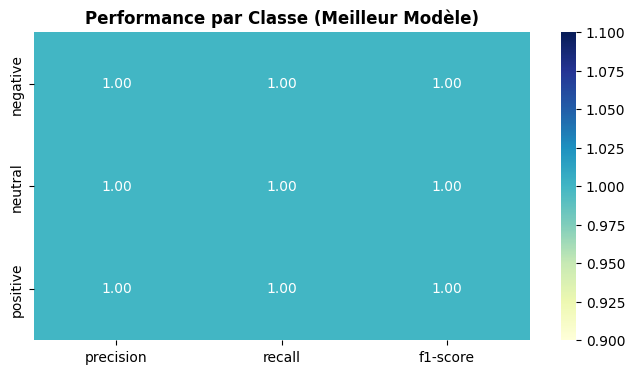

In [9]:
# === 🔹 PERFORMANCE PAR CLASSE (Analyse d'Erreurs détaillée) ===
import seaborn as sns

report = classification_report(y_test, y_pred_sbert, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose().iloc[:len(class_names), :] 

plt.figure(figsize=(8, 4))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Performance par Classe (Meilleur Modèle)", fontweight='bold')
plt.show()

### 🔹 7. MATRICE DE CONFUSION

C:\Users\user\AppData\Local\Temp\ipykernel_25848\2698735776.py:18: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


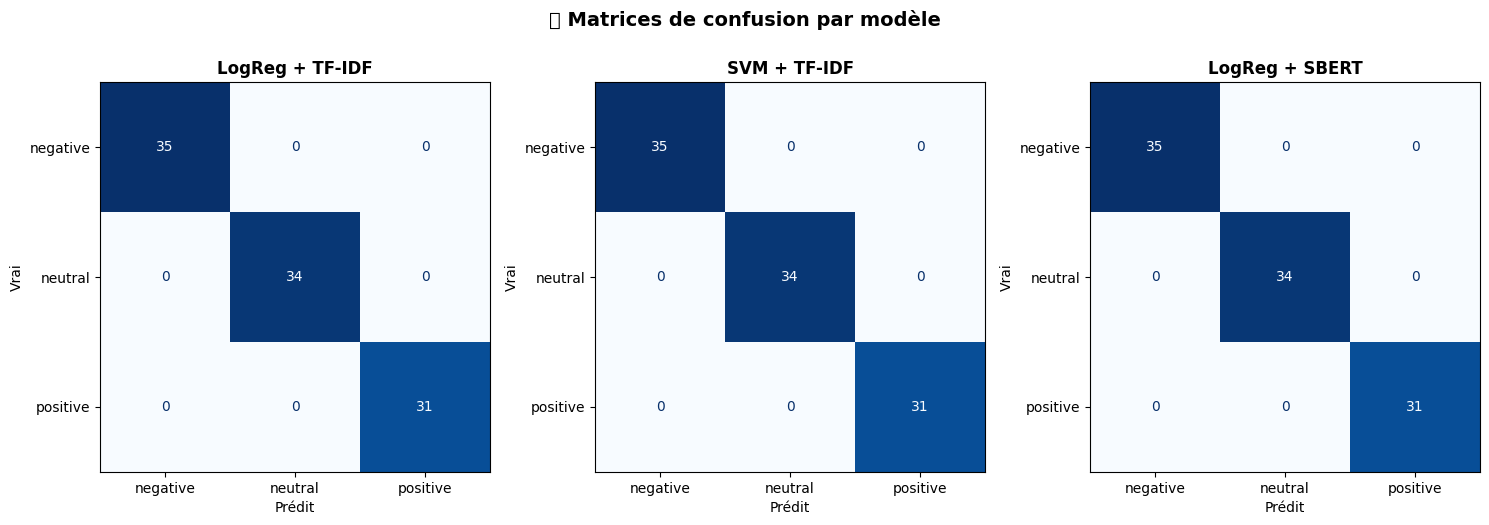

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_preds = [
    (y_pred_lr, "LogReg + TF-IDF"),
    (y_pred_svm, "SVM + TF-IDF"),
    (y_pred_sbert, "LogReg + SBERT")
]

for ax, (preds, name) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds, labels=np.unique(y_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Vrai')

plt.suptitle("🔍 Matrices de confusion par modèle", fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 🔹 8. ANALYSE DES ERREURS (CRITIQUE)

In [11]:
print("🔎 Analyse des erreurs du meilleur modèle (SBERT + LogReg)...")

# Indices mal classés
misclassified_idx = np.where(y_test != y_pred_sbert)[0]
# Map back to original dataframe indices
original_mis_idx = idx_test[misclassified_idx]

# Afficher 5 exemples
print(f"\n {len(misclassified_idx)} avis mal classés sur {len(y_test)} tests.")
print("📖 Exemples d'erreurs :\n")

for i in original_mis_idx[:5]:
    true_label = y_labels[i]
    pred_label = le.inverse_transform([y_pred_sbert[misclassified_idx[np.where(idx_test == i)[0][0]]]])[0]
    text = texts[i][:100]  # Tronquer pour l'affichage
    print(f"🔹 Vrai: {true_label.upper()} | Prédit: {pred_label.upper()}")
    print(f"   Texte : \"{text}...\"\n")

🔎 Analyse des erreurs du meilleur modèle (SBERT + LogReg)...

 0 avis mal classés sur 100 tests.
📖 Exemples d'erreurs :



### 🔹 9. SAUVEGARDER LE MEILLEUR MODÈLE

In [12]:
import os
os.makedirs("../outputs/models/", exist_ok=True)

# Sauvegarder le meilleur pipeline (ici SBERT + LogReg)
best_model = {
    'vectorizer_type': 'SBERT',
    'model_name': 'LogisticRegression',
    'model': lr_sbert,
    'label_encoder': le,
    'metrics': df_metrics.set_index('Modèle').loc['LogReg + SBERT'].to_dict()
}

joblib.dump(best_model, "../outputs/models/best_sentiment_mono.pkl")
print("✅ Meilleur modèle sauvegardé : ../outputs/models/best_sentiment_mono.pkl")

# Pour inférence future :
# model = joblib.load("../outputs/models/best_sentiment_mono.pkl")
# preds = model['model'].predict(new_embeddings)

✅ Meilleur modèle sauvegardé : ../outputs/models/best_sentiment_mono.pkl
